In [ ]:
import blackjax
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # notebook is in Toy Data/; Better_HMC.py is one level up
import jax.numpy as jnp
import jax.scipy as jsp
import numpy as np
import jax
import jax.random as jr
import arviz as az
import jax.scipy.special as jss
from functools import partial
# Import the custom package you generated
from Better_HMC import HMCSampler 
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)


num_dimensions = 250
num_data = 100
noise_magnitude_on_each_point = 0.1
num_fourier_entries = 350
total_length = 0.5
## Very important: Dividing by num_dims - 1 is inconsistent with the other notebooks that fit two params. If I divide by num_dims instead, then I am essentially
## measuring the field at bin centers instead of bin edges which is more consistent with the 2D case, but then some field on each edge is not measured
dx = total_length/(num_dimensions - 1)
fixed_points_linspace = jnp.arange(num_dimensions)*dx 
full_fourier_period_linspace = jnp.arange(num_fourier_entries)*dx 
#If we only divide by num_dims: boundary_padding = total_length*(num_fourier_entries/num_dimensions - 1)
boundary_padding = total_length*((num_fourier_entries - num_dimensions)/(num_dimensions - 1))
omegas = 2 * jnp.pi * jnp.fft.fftfreq(num_fourier_entries, d = dx)
num_fitting_params = 2
normalization_factor = num_fourier_entries/jnp.sqrt(total_length + boundary_padding)

fixed_logscale = 0
hardcoded_logvar = 0
hardcoded_lognu = jnp.log(0.5)

num_overall_steps = 6000
burn_in = 1000

num_integration_steps = 100
step_size = 0.011

use_NUTS = False
use_blackjax_hmc = False
window_adapt_square_mass_matrix = False

def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, lognu = inference_params
        # Scale is fixed
        logscale = fixed_logscale
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))

def matern_magnitude(omegas, inference_params):
     return jnp.sqrt(general_matern_spectral_density(omegas, inference_params))


def hartley(x):
    X = jnp.fft.fft(x)
    return jnp.real(X) - jnp.imag(X)

def fft_field_hartley(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    H = noise * raw_average_amplitude_data          # elementwise, whole array, in order
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_dimensions]

def fft_field(noise, inference_params):
    return fft_field_hartley(noise, inference_params)

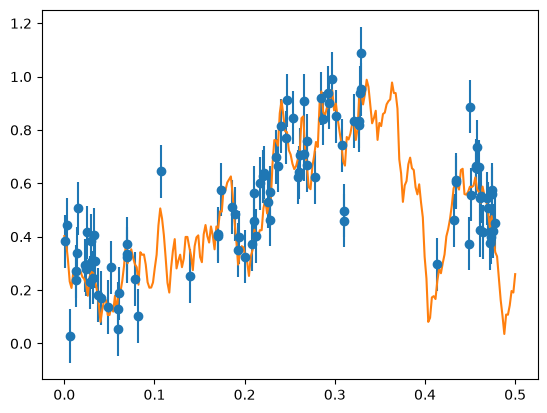

In [201]:
def cdf(x):
    return x + jnp.sin(4 * jnp.pi * x) / (4 * jnp.pi)

def pdf(x):
    return 1 + jnp.cos(4 * jnp.pi * x)

@partial(jax.jit, static_argnames=("n", "iters"))
def sample(key, n, iters=8):
    u = jr.uniform(key, (n,))
    x = u  # good initial guess since CDF(x) ≈ x on average
    for _ in range(iters):
        x = x - (cdf(x) - u) / pdf(x)   # Newton's method
        x = jnp.clip(x, 0.0, 1.0)
    return x

diagonal_values = jnp.ones(num_data)*noise_magnitude_on_each_point**2

cov_data_matrix = jnp.diag(diagonal_values)
inv_cov_data_matrix = jnp.linalg.inv(cov_data_matrix)

k1, k2, k3, k4 = jr.split(jr.key(25), 4)
x_obs = sample(k1, num_data)*total_length
xi = jr.normal(k3, shape = num_fourier_entries)
true_field = fft_field(xi, (hardcoded_logvar, hardcoded_lognu))
y_obs_true = jnp.interp(x_obs, fixed_points_linspace, true_field)
#y_obs_true = jnp.sin(30*x_obs/10) * jnp.exp(-5*x_obs/10)
y_obs_err = noise_magnitude_on_each_point * jnp.ones_like(y_obs_true)
noise = y_obs_err * jr.normal(k2, shape=y_obs_true.shape)
y_obs = y_obs_true + noise

plt.errorbar(x_obs, y_obs, yerr = noise_magnitude_on_each_point, fmt='o', label='Observations')

plt.plot(fixed_points_linspace, true_field)
def response_function(xi, inference_params):
    field_points = fft_field(xi, inference_params)
    return jnp.interp(x_obs, fixed_points_linspace, field_points)


In [ ]:
def logvarprior(logvar):
    return -0.5*logvar*logvar
def logscaleprior(logscale):
    return -0.5*logscale*logscale
def lognuprior(lognu):
    return -0.5*lognu*lognu

def negative_logdensity(x):
    logvar = x[0]
    lognu = x[1]
    xi = x[2:]
    inference_params = (logvar, lognu)
    negative_log_p_s = -logvarprior(logvar) - lognuprior(lognu) + 0.5*xi.T @ xi
    R = jax.jacobian(lambda xi: response_function(xi, inference_params))(jnp.zeros(num_fourier_entries))
    res = y_obs - response_function(xi, inference_params)
    negative_log_p_d_given_s = 0.5*res.T @ inv_cov_data_matrix @ res
    return negative_log_p_s + negative_log_p_d_given_s




In [203]:
num_good_samples = num_overall_steps - burn_in
time_arr = jnp.arange(num_good_samples)


# NUTS samples a POSITIVE log-density, so negate your negative one.
logdensity_fn = lambda x: -negative_logdensity(x)

rng = jr.PRNGKey(5)
rng, k1, k2 = jr.split(rng, 3)
initial_coordinates = jnp.zeros(num_fourier_entries + num_fitting_params)
initial_coordinates = initial_coordinates.at[0].set(hardcoded_logvar)
initial_coordinates = initial_coordinates.at[1].set(hardcoded_lognu)

if(use_NUTS):
        def inference_loop(rng_key, kernel, initial_state, num_samples):
            @jax.jit
            def one_step(state, key):
                state, info = kernel(key, state)
                return state, (state, info)
            keys = jr.split(rng_key, num_samples)
            _, (states, infos) = jax.lax.scan(one_step, initial_state, keys)
            return states, infos


        warmup = blackjax.window_adaptation(blackjax.nuts, logdensity_fn, is_mass_matrix_diagonal= not window_adapt_square_mass_matrix)
        (state, parameters), _ = warmup.run(k1, initial_coordinates, num_steps=burn_in)
        nuts = blackjax.nuts(logdensity_fn, **parameters)
        initial_state = state

        states, infos = inference_loop(k2, nuts.step, initial_state, num_good_samples)

        overall_data_arr = states.position
        accept_prob_arr  = infos.acceptance_rate
elif use_blackjax_hmc:
    def inference_loop(rng_key, kernel, initial_state, num_samples):
        @jax.jit
        def one_step(state, key):
            state, info = kernel(key, state)
            return state, (state, info)
        keys = jr.split(rng_key, num_samples)
        _, (states, infos) = jax.lax.scan(one_step, initial_state, keys)
        return states, infos

    # HMC needs num_integration_steps; pass it through window_adaptation.
    warmup = blackjax.window_adaptation(
        blackjax.hmc, logdensity_fn,
        num_integration_steps=num_integration_steps,
        is_mass_matrix_diagonal=not window_adapt_square_mass_matrix,
    )
    (state, parameters), _ = warmup.run(k1, initial_coordinates, num_steps=burn_in)

    # ...and again when building the tuned kernel.
    hmc = blackjax.hmc(logdensity_fn, **parameters)
    initial_state = state

    states, infos = inference_loop(k2, hmc.step, initial_state, num_good_samples)

    overall_data_arr = states.position
    accept_prob_arr  = infos.acceptance_rate
    np.save('blackjax_cov_matrix.npy', np.asarray(parameters["inverse_mass_matrix"]))
else :
    sampler = HMCSampler(
        negative_logdensity= negative_logdensity,
        num_integration_steps =  num_integration_steps,
        step_size= step_size,
        inv_mass_matrix = jnp.eye(num_fourier_entries + num_fitting_params),
        #inv_mass_matrix = jnp.diag(jnp.array(np.load('blackjax_cov_matrix.npy'))),
        alpha=1.0
    )

    overall_data_arr, overall_momentum_arr, accept_prob_arr = sampler.sample(
        start_position=initial_coordinates, 
        num_samples=num_overall_steps,
        burn_in = burn_in,
        rng_key=rng
    )

#overall_data_arr = jnp.zeros(shape = (num_good_samples, num_fourier_entries + num_fitting_params))
#accept_prob_arr = jnp.zeros(shape = num_good_samples)
logvars = overall_data_arr[:, 0]
lognus = overall_data_arr[:, 1]
overall_position_arr = overall_data_arr[:, 2:]  
logscales = jnp.zeros_like(logvars)
inference_params = (logvars, lognus)

overall_position_arr = jax.vmap(fft_field, in_axes=(0, 0))(
    overall_position_arr, inference_params
)
overall_position_arr = overall_position_arr[:, 0:num_dimensions]

mean_position = overall_position_arr.sum(axis=0)/num_good_samples

vars = jnp.exp(logvars)
scales = jnp.exp(logscales)
nus = jnp.exp(lognus)
cov= jnp.cov(overall_data_arr, rowvar = False)

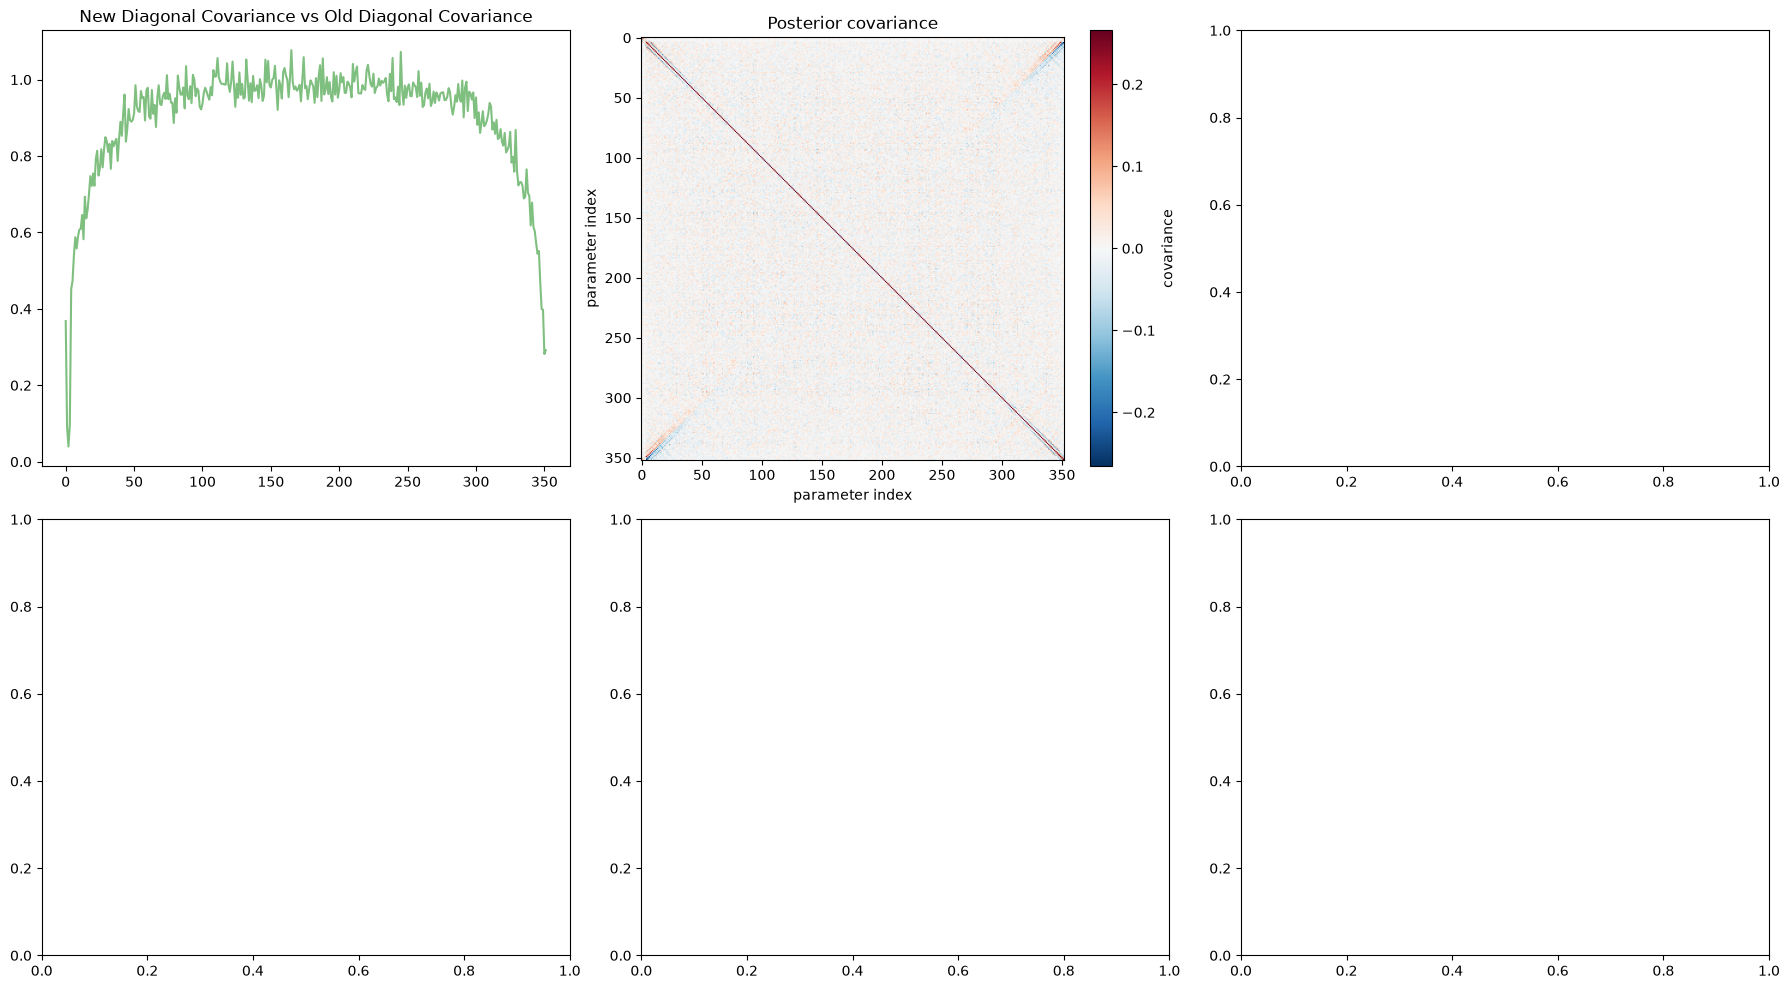

In [ ]:
fig, axes = plt.subplots(2, 3, figsize = (18, 10))
timegrid = jnp.arange(num_fourier_entries + num_fitting_params)
axes[0][0].plot(timegrid, jnp.diagonal(cov), color = "Green", alpha = 0.5)
#axes[0].plot(timegrid, jnp.diagonal(old_cov), color = "Red", alpha = 0.5)
axes[0][0].set_title("New Diagonal Covariance vs Old Diagonal Covariance")


C = np.asarray(cov)
off = C - np.diag(np.diag(C))
vmax = np.abs(off).max()         # symmetric limits so white = 0
im = axes[0][1].imshow(C, cmap='RdBu_r', vmin= -vmax, vmax=vmax)
fig.colorbar(im, ax=axes[0][1], label='covariance')
axes[0][1].set_title('Posterior covariance')
axes[0][1].set_xlabel('parameter index')
axes[0][1].set_ylabel('parameter index')


if use_NUTS or use_blackjax_hmc:
    step_size = parameters['step_size']
    inv_mass_matrix = parameters['inverse_mass_matrix']   # not 'inv_mass_matrix'
    if(window_adapt_square_mass_matrix):
        C = np.asarray(inv_mass_matrix)
        off = C - np.diag(np.diag(C))
        vmax = np.abs(off).max()        
        im = axes[1][0].imshow(jnp.log(C), cmap='RdBu_r', vmin= -vmax, vmax=vmax)
        axes[1][0].colorbar(im, ax=axes[0], label='covariance')
        axes[1][0].set_title('Posterior covariance')
        axes[1][0].set_xlabel('parameter index')
        axes[1][0].set_ylabel('parameter index')
        axes[1][1].plot(jnp.arange(jnp.diagonal(inv_mass_matrix)).size, inv_mass_matrix)
    else :
        axes[1][0].plot(jnp.arange(inv_mass_matrix.size), inv_mass_matrix)

plt.tight_layout()
plt.show()

ESS for variance: 637.9808303738906
KL_divergence is 0.1352652434159944 with jitter 0.0002
Average acceptance probability (acceptance rate) is: 0.8194175108459211
Num overall steps: 6000 Hardcoded logvar: 0 Fixed_logscale: 0 Hardcoded lognu: -0.6931471805599453
Use NUTS? False Use blackjax HMC? False Step Size: 0.011 Num integration steps (only valid if no NUTS) 100
Num dimensions: 250 Num data: 100 Total length: 0.5 Noise on each point: 0.1 Num HMC trials: 6000
Average chi_2 statistic based on the prior: 0.9075780323527299
Average chi_2 statistic based on the data per data point: 0.9259326449299445
Binning of the analytical posterior (finer bins --> lower KL div): 40 by 40


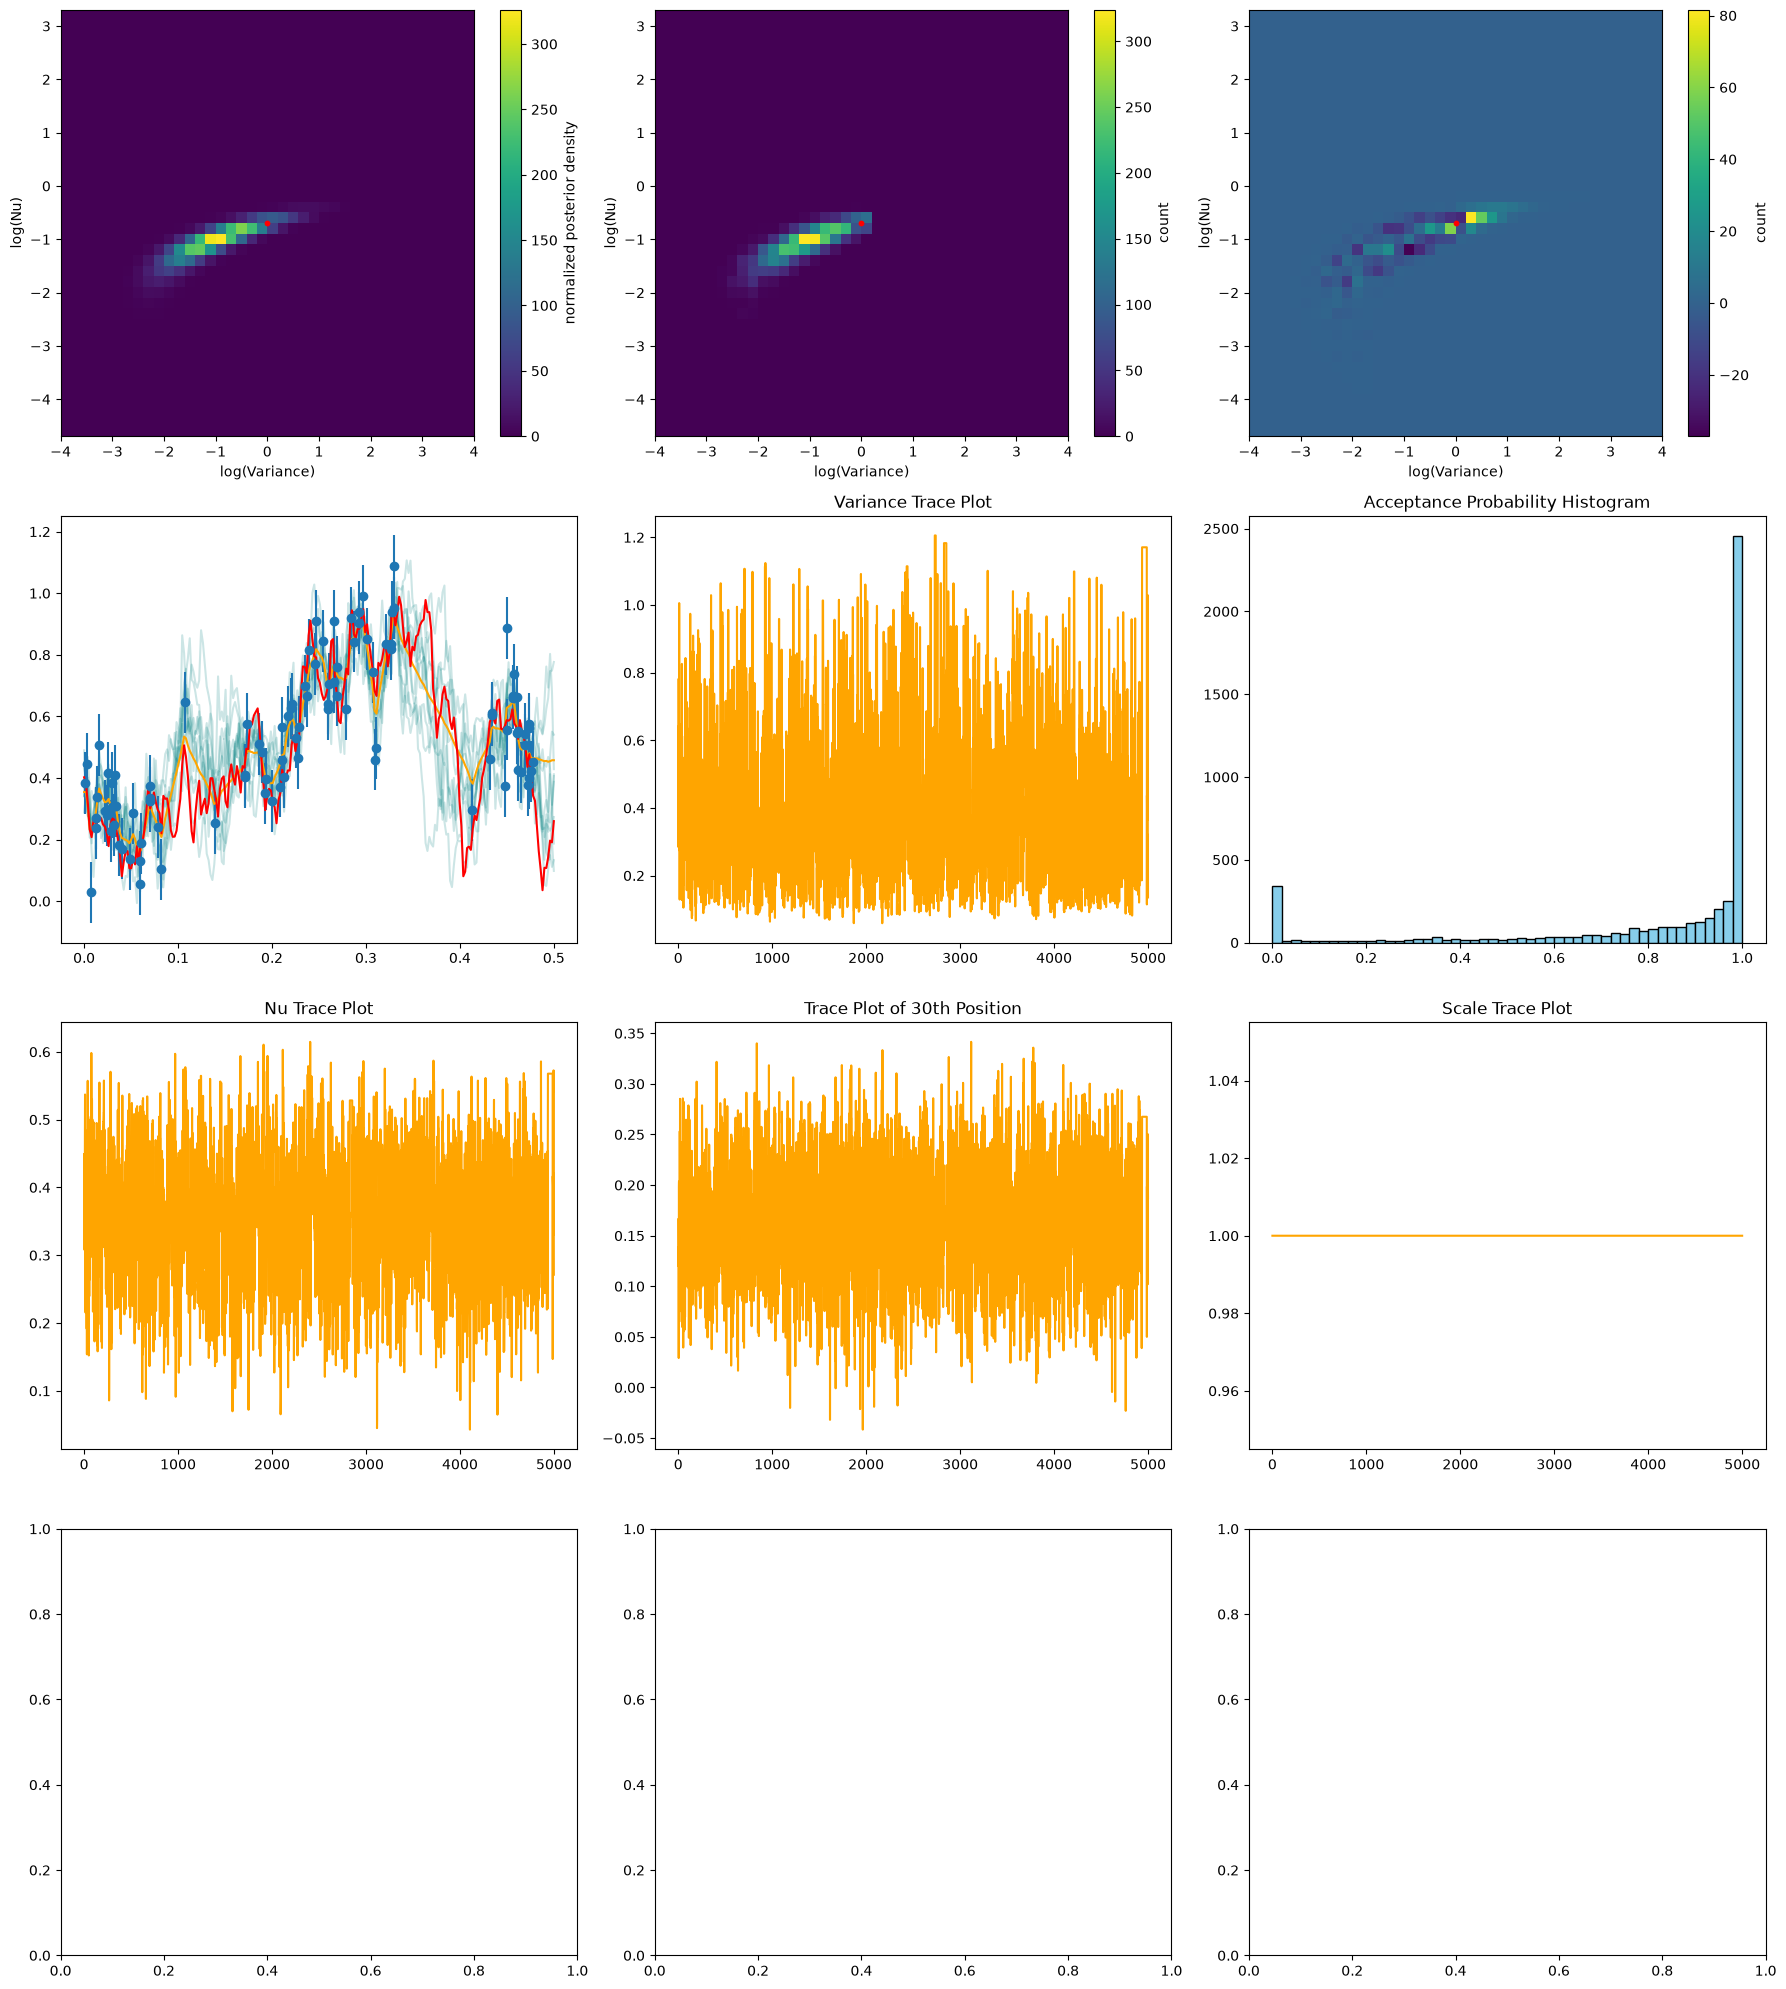

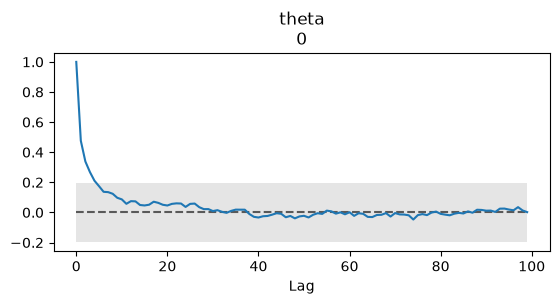

In [205]:
fig, axes = plt.subplots(4, 3, figsize = (18, 20))
for i in range (0, 10):
    axes[1][0].plot(fixed_points_linspace, overall_position_arr[500*i, :], color = "teal", alpha = 0.2)

axes[1][0].errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')
axes[1][0].plot(fixed_points_linspace, mean_position, color = "orange", alpha = 1)
axes[1][0].plot(fixed_points_linspace, true_field, color = "red", alpha = 1)


def log_posterior_density(inference_params):
    logvar, lognu = inference_params
    logprior = logvarprior(logvar) + lognuprior(lognu)
    
    R = jax.jacobian(lambda xi: response_function(xi, inference_params))(jnp.zeros(num_fourier_entries))
    jitter = 0
    total_cov_on_data = R @ R.T + cov_data_matrix + jitter
    cho_factor = jsp.linalg.cho_factor(total_cov_on_data)
    solve_val = jsp.linalg.cho_solve(cho_factor, y_obs)
    log_p_data_given_params = -0.5 * (y_obs @ solve_val)
    logdet = 2.0 * jnp.sum(jnp.log(jnp.diag(cho_factor[0])))
    return log_p_data_given_params + logprior - 0.5 * logdet 

def max_log_posterior_density(inference_params):
    log_pd = log_posterior_density(inference_params)
    R = jax.jacobian(lambda xi: response_function(xi, inference_params))(jnp.zeros(num_fourier_entries))
    D = jnp.linalg.inv(jnp.eye(num_fourier_entries) + R.T @ inv_cov_data_matrix @ R)
    _, logdet = jnp.linalg.slogdet(D)
    return log_pd - 0.5*logdet


number_bins_x = 40
number_bins_y = 40

x_min, x_max = hardcoded_logvar - 4, hardcoded_logvar + 4
y_min, y_max = hardcoded_lognu - 4, hardcoded_lognu + 4
dx = (x_max - x_min)/number_bins_x
dy = (y_max - y_min)/number_bins_y

x_centers = (jnp.arange(number_bins_x) + 0.5)*dx + x_min
y_centers = (jnp.arange(number_bins_y) + 0.5)*dy + y_min
x_edges = jnp.arange(number_bins_x + 1)*dx + x_min
y_edges = jnp.arange(number_bins_y + 1)*dy + y_min

X, Y = jnp.meshgrid(x_centers, y_centers, indexing='ij')

F = jax.jit(lambda lv, ln: log_posterior_density((lv, ln)))
Z_flat = jax.lax.map(lambda pair: F(pair[0], pair[1]), (X.ravel(), Y.ravel()))

Z = Z_flat.reshape(X.shape) 
Z = jnp.exp(Z - jnp.max(Z))
expected_posterior_counts = Z*num_good_samples/jnp.sum(Z)

im = axes[0][0].imshow(
    expected_posterior_counts.T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[0][0], label='normalized posterior density')

H_HMC_samples, _, _ = jnp.histogram2d(logvars, lognus, bins=[x_edges, y_edges])

im2 = axes[0][1].imshow(
    H_HMC_samples.T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im2, ax=axes[0][1], label='count')

im3 = axes[0][2].imshow(
    (expected_posterior_counts - H_HMC_samples).T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im3, ax=axes[0][2], label='count')

axes[0][0].scatter(hardcoded_logvar, hardcoded_lognu, color = 'red', s = 10, zorder = 3)
axes[0][1].scatter(hardcoded_logvar, hardcoded_lognu, color = 'red', s = 10, zorder = 3)
axes[0][2].scatter(hardcoded_logvar, hardcoded_lognu, color = 'red', s = 10, zorder = 3)
axes[0][0].set_xlabel("log(Variance)")
axes[0][0].set_ylabel("log(Nu)")
axes[0][1].set_xlabel("log(Variance)")
axes[0][1].set_ylabel("log(Nu)")
axes[0][2].set_xlabel("log(Variance)")
axes[0][2].set_ylabel("log(Nu)")
axes[1][1].plot(time_arr, vars, color = "Orange")
axes[1][1].set_title("Variance Trace Plot")
axes[2][2].plot(time_arr, scales, color = "Orange")
axes[2][2].set_title("Scale Trace Plot")
axes[2][0].plot(time_arr, nus, color = "Orange")
axes[2][0].set_title("Nu Trace Plot")
axes[2][1].plot(time_arr, overall_position_arr[:, 30], color = "Orange")
axes[2][1].set_title("Trace Plot of 30th Position")
axes[1][2].set_title("Acceptance Probability Histogram")
axes[1][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

fig.tight_layout()


posterior_samples = overall_data_arr[np.newaxis, :, :]  # add chain axis -> (1, num_samples, 50)

idata = az.from_dict({"posterior": {"theta": posterior_samples}})
param_index = 0  # which of your 50 parameters you want

az.plot_autocorr(idata, var_names="theta", coords={"theta_dim_0": [param_index]})

ess_all = az.ess(idata, var_names="theta")  # a Dataset, ESS for all 50 parameters at once

ess_param = ess_all["theta"].sel(theta_dim_0=param_index).values
print(f"ESS for variance: {ess_param}")

def KL_divergence(expected_probs, observed_probs, jitter):
    usable_expected_probs = jnp.where(expected_probs == 0, jitter, expected_probs)
    usable_observed_probs = jnp.where(observed_probs == 0, jitter, observed_probs)
    KL_array = usable_expected_probs*(jnp.log(usable_expected_probs) - jnp.log(usable_observed_probs))
    return jnp.sum(KL_array)
def average_chi_2_based_on_data(x_data, x_field, data, field, inverse_data_cov):
    interp_all_rows = jax.vmap(lambda row: jnp.interp(x_data, x_field, row))
    raw_field_at_data_points = interp_all_rows(field)
    residuals = raw_field_at_data_points - data
    chi_2 = jnp.einsum('ij,jk,ik->i', residuals, inverse_data_cov, residuals)
    return jnp.average(chi_2)/data.size

expected_bin_prob = expected_posterior_counts/num_good_samples
observed_bin_prob = H_HMC_samples/num_good_samples
print(f"KL_divergence is {KL_divergence(expected_bin_prob, observed_bin_prob, jitter = 1/num_good_samples)} with jitter {1/num_good_samples}")
print(f"Average acceptance probability (acceptance rate) is: {jnp.average(accept_prob_arr)}")
print(f"Num overall steps: {num_overall_steps} Hardcoded logvar: {hardcoded_logvar} Fixed_logscale: {fixed_logscale} Hardcoded lognu: {hardcoded_lognu}")
print(f"Use NUTS? {use_NUTS} Use blackjax HMC? {use_blackjax_hmc} Step Size: {step_size} Num integration steps (only valid if no NUTS) {num_integration_steps}")
print(f"Num dimensions: {num_dimensions} Num data: {num_data} Total length: {total_length} Noise on each point: {noise_magnitude_on_each_point} Num HMC trials: {num_overall_steps}")
prior_variances = jnp.diag(cov)[2:]
print(f"Average chi_2 statistic based on the prior: {jnp.average(prior_variances)}")
print(f"Average chi_2 statistic based on the data per data point: {average_chi_2_based_on_data(x_obs, fixed_points_linspace, y_obs, overall_position_arr, inv_cov_data_matrix)}")
print(f"Binning of the analytical posterior (finer bins --> lower KL div): {number_bins_x} by {number_bins_y}")